DPEL Mini Project: Spotify Tracks Dataset Analysis
---


**Introduction:**
---
Spotify is one of the largest digital music streaming platforms, providing access to millions of songs enriched with detailed audio features that describe various musical characteristics. These features capture aspects such as rhythm, intensity, mood, and acoustic properties, enabling deeper analytical insights into music beyond basic metadata.

In this project, a Spotify tracks dataset is utilized to perform systematic data preprocessing and exploratory data analysis. The dataset is initially well-structured and clean; however, controlled data degradation is intentionally introduced to demonstrate preprocessing techniques as required by the evaluation rubric. The objective is to ensure that the dataset is cleaned, transformed, and analyzed effectively, forming a strong foundation for building a music recommendation system in subsequent stages.

In [ ]:
#Basic Prerequisites
!pip install numpy
!pip install scipy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn


#Libraries for Sound Analysis
!pip install yt-dlp librosa
!pip install imageio-ffmpeg
!pip install static-ffmpeg



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#Prerequisites

import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer, KNNImputer

import yt_dlp
import librosa
import numpy as np
import pandas as pd
import os
import warnings
import subprocess
import imageio_ffmpeg

In [4]:
#Data Loading

df1 = pd.read_csv("spotify tracks dataset - primary.csv")
print("Loaded Succesfully...")

Loaded Succesfully...


**A) Data Understanding:**
---
Spotify hosts a vast collection of tracks characterized by multiple audio features that quantitatively describe musical attributes. These features enable objective comparison between songs and are essential for analytical tasks such as clustering, similarity computation, and recommendation systems.

This project focuses on analyzing Spotify track data using its audio features to understand patterns in musical characteristics. Proper data understanding is essential before applying preprocessing techniques, as it ensures that transformations are meaningful and aligned with the structure of the dataset.




**2. Problem Statement:**
The objective of this project is to analyze Spotify songs using their audio features such as energy, danceability, tempo, and popularity to identify patterns in music characteristics. Understanding these relationships helps in identifying factors that influence listener preferences. This analysis serves as the foundation for building a recommendation system that suggests songs based on similarity in audio features.

**This analysis has real-world applications in music streaming platforms such as Spotify, where understanding audio features and user preferences can help improve recommendation systems, increase user engagement, and enhance personalized music suggestions.**

**3. Dataset Description**






*   Attributes/Features:


The dataset contains multiple features describing songs, including track name, artist name, and various audio characteristics. Key features include danceability (suitability for dancing), energy (intensity), tempo (speed in BPM), valence (emotional positivity), loudness (sound intensity), acousticness (probability of being acoustic), and popularity (listener engagement metric). Additionally, categorical features such as track genre are included.

Danceability measures how suitable a track is for dancing based on rhythm and beat.
Energy represents the intensity and activity level of a track.
Tempo indicates the speed of a song in beats per minute.
Valence describes the positivity or mood of a track.
Loudness measures the overall sound intensity in decibels.
Acousticness indicates whether a track is acoustic in nature.
Popularity reflects how frequently a song is streamed on a scale from 0 to 100.

In [5]:
#Info of Dataset:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [6]:
#Description of dataset:
df1.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000




*   Dataset Size:

The dataset contains 114000 rows and 21 columns, where each row represents a unique song and each column represents a specific feature.






In [7]:
#Number of Rows and Columns in Dataset along with total size:
print(f"The number of Rows is {df1.shape[0]} and The Number of Columns (features) are {df1.shape[1]}")
print(f"Total Size of Dataset: {df1.shape}")
print("Total cell count in Dataset: ", df1.size)

The number of Rows is 114000 and The Number of Columns (features) are 21
Total Size of Dataset: (114000, 21)
Total cell count in Dataset:  2394000




*   Target Variable: The target variable is the genre for ML but none for exploratory data analysis task. However, popularity can be considered as an important variable for analysis.


* Genre:

In [8]:
#To print the count of songs for each genre
genre_counts = df1['track_genre'].value_counts()
print(genre_counts)

track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
               ... 
techno         1000
trance         1000
trip-hop       1000
turkish        1000
world-music    1000
Name: count, Length: 114, dtype: int64


Thus, 1000 Entries of 114 Genres each

**4. Initial Observations**

The dataset is observed to be highly clean with negligible missing values and minimal duplicate entries. Most numerical features fall within expected ranges, indicating high data quality.



In [10]:
#Displaying number of missing values:
print("Missing Values:")
print("=" *22)
print(df1.isnull().sum())

#Displaying Number of Duplicate Tracks
duplicate_tracks_count = df1.duplicated(subset=['track_id']).sum()
print("=" *22)
print(f"Number of duplicate tracks (same song, different genre): {duplicate_tracks_count}")

#Displaying Number of Duplicate Rows
print("=" *22)
print("\nPure Duplicates:", df1.duplicated().sum())

Missing Values:
Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Number of duplicate tracks (same song, different genre): 24259

Pure Duplicates: 0


**Artificial Data Degradation**
---


As, The Dataset is already quite clean, Controlled data degradation is performed only for demonstration purposes to showcase preprocessing techniques as required by the evaluation criteria.

In [11]:
#Creating a copy of original dataset to avoid destructive editing:
df_corrupt = df1.copy()

#Dropping "Unnamed" column since it only serves as index:
df_corrupt = df_corrupt.drop("Unnamed: 0", axis=1)

#Replacing 5% of values in numerical columns with null/NaN values:
for col in df_corrupt.select_dtypes(include=[np.number]).columns:
    df_corrupt.loc[df_corrupt.sample(frac=0.05).index, col] = np.nan

#Introducing 2% outlier values in numerical columns:
for col in df_corrupt.select_dtypes(include=[np.number]).columns:
    idx = df_corrupt.sample(frac=0.02).index
    df_corrupt.loc[idx, col] *= 3

#Introducing 1% values as duplicates in the Dataset:
df_corrupt = pd.concat([df_corrupt, df_corrupt.sample(frac=0.01)])

In [12]:
#Displaying corrupt dataset:
df_corrupt.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73.0,230666.0,False,0.676,0.4610,1.0,-6.746,0.0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4.0,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55.0,149610.0,False,0.420,0.1660,1.0,-17.235,1.0,0.0763,0.9240,0.000006,NaN,0.267,77.489,4.0,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57.0,210826.0,False,1.314,0.3590,0.0,-9.734,1.0,0.0557,0.2100,0.000000,0.1170,0.120,NaN,4.0,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71.0,201933.0,False,0.266,0.0596,0.0,-18.515,1.0,0.0363,0.9050,0.000212,0.1320,0.143,181.740,3.0,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82.0,198853.0,False,0.618,0.4430,2.0,-9.681,1.0,0.0526,0.4690,0.000000,0.0829,0.167,119.949,12.0,acoustic


Checking Again:

In [13]:
#Displaying number of missing values:
print("Missing Values:")
print("=" *22)
print(df_corrupt.isnull().sum())

#Displaying Number of Duplicate Tracks
duplicate_tracks_count = df_corrupt.duplicated(subset=['track_id']).sum()
print("=" *22)
print(f"Number of duplicate tracks (same song, different genre): {duplicate_tracks_count}")

#Displaying Number of Duplicate Rows
print("=" *22)
print("\nPure Duplicates:", df_corrupt.duplicated().sum())

#Note: Pure duplicates were artificially added by us. They are entire duplicated rows.
#Note: Track duplicates are duplicates in the original dataset. These caused errors during modeling and visualization.

Missing Values:
track_id               0
artists                1
album_name             1
track_name             1
popularity          5754
duration_ms         5764
explicit               0
danceability        5758
energy              5755
key                 5747
loudness            5754
mode                5754
speechiness         5764
acousticness        5755
instrumentalness    5754
liveness            5758
valence             5751
tempo               5748
time_signature      5762
track_genre            0
dtype: int64
Number of duplicate tracks (same song, different genre): 25399

Pure Duplicates: 1214


**B) Data Preprocessing:**
---





**5. Handling Missing Values:**

Mean imputation preserves the central tendency of numerical data without introducing bias, it is suitable for continuous type of data.

KNN imputation is highly effective when missing data is not purely random but depends on other observable variables, providing higher accuracy than simple mean/median imputation.

Mode imputation is appropriate for categorical variables. This ensures no data loss while maintaining dataset integrity.

In [ ]:
#Separating Numerical, Categorical and Discreet columns:
num_cols = ['danceability','energy','loudness','speechiness',
'acousticness','instrumentalness','liveness','valence','tempo']
cat_cols = df_corrupt.select_dtypes(include=['object']).columns
disc_cols = ['popularity','duration_ms','key','mode','time_signature']

#Defining imputers:
mean_imputer = SimpleImputer(strategy='mean')
knn_imputer = KNNImputer(n_neighbors=5)
mode_imputer = SimpleImputer(strategy='most_frequent')

for col in num_cols:
    df_corrupt[col] = mean_imputer.fit_transform(df_corrupt[[col]])[:, 0]

for col in cat_cols:
    df_corrupt[col] = mode_imputer.fit_transform(df_corrupt[[col]])[:, 0]

for col in disc_cols:
    df_corrupt[col] = knn_imputer.fit_transform(df_corrupt[[col]])[:, 0]

#Note: [:, 0] is to ensure the result is a 2D array which is needed 
# for sklearn methods. We get an error otherwise.

C:\Users\irxchand\AppData\Local\Temp\ipykernel_32504\2608318035.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_corrupt.select_dtypes(include=['object']).columns


In [15]:
#Displaying number of missing values:
print("Missing Values:")
print("=" *22)
print(df_corrupt.isnull().sum())

#Displaying Number of Duplicate Tracks
duplicate_tracks_count = df_corrupt.duplicated(subset=['track_id']).sum()
print("=" *22)
print(f"Number of duplicate tracks (same song, different genre): {duplicate_tracks_count}")

#Displaying Number of Pure Duplicate Rows
print("=" *22)
print("\nPure Duplicates:", df_corrupt.duplicated().sum())

Missing Values:
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Number of duplicate tracks (same song, different genre): 25399

Pure Duplicates: 1214


**6. Data Cleaning:**

Duplicate entries are removed to ensure uniqueness, and incorrect values are corrected by restricting them within valid ranges.


In [16]:
#Removing duplicate track rows:
df_corrupt = df_corrupt.drop_duplicates(subset=['track_id']).copy()


#Fixing out of range values using clipping:
bounded = ['danceability','energy','valence','acousticness']
for col in bounded:
    df_corrupt.loc[:, col] = df_corrupt[col].clip(0,1)
df_corrupt.loc[:, 'popularity'] = df_corrupt['popularity'].clip(0,100)

In [17]:
#Displaying number of missing values:
print("Missing Values:")
print("=" *22)
print(df_corrupt.isnull().sum())

#Displaying Number of Duplicate Tracks
duplicate_tracks_count = df_corrupt.duplicated(subset=['track_id']).sum()
print("=" *22)
print(f"Number of duplicate tracks (same song, different genre): {duplicate_tracks_count}")

#Displaying Number of Duplicate Rows
print("=" *22)
print("\nPure Duplicates:", df_corrupt.duplicated().sum())

Missing Values:
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Number of duplicate tracks (same song, different genre): 0

Pure Duplicates: 0


Comparison of Before and After:

======================        ======================
Missing Values:               Missing Values:
======================        ======================
track_id               0      track_id            0
artists                1      artists             0
album_name             1      album_name          0
track_name             1      track_name          0
popularity          5757      popularity          0
duration_ms         5746      duration_ms         0
explicit               0      explicit            0
danceability        5758      danceability        0
energy              5762      energy              0
key                 5759      key                 0
loudness            5776      loudness            0
mode                5753      mode                0
speechiness         5762      speechiness         0
acousticness        5768      acousticness        0
instrumentalness    5767      instrumentalness    0
liveness            5759      liveness            0
valence             5762      valence             0
tempo               5744      tempo               0
time_signature      5752      time_signature      0
track_genre            0      track_genre         0
dtype: int64                dtype: int64

======================        ======================
Duplicate Tracks: 25399       Duplicate Tracks: 0
======================        ======================

Pure Duplicates: 1209         Pure Duplicates: 0

**7. Feature Transformation:**

Categorical variables are prepared for transformation to ensure compatibility with numerical operations and modeling techniques.



In [18]:
#Selecting categorical columns:
categorical_cols = df_corrupt.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", categorical_cols)
print()

#Converting to str
for col in categorical_cols:
    df_corrupt[col] = df_corrupt[col].astype(str)

print("\nAll categorical columns converted to string type for consistency.")
print()

#Selecting numeric columns:
numeric_cols = df_corrupt.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical columns:", numeric_cols)
print()

#Converting to numeric and changing invalid values to Null/Nan
for col in numeric_cols:
    df_corrupt[col] = pd.to_numeric(df_corrupt[col], errors='coerce')

print("\nAll numerical columns ensured to be in correct numeric format.")
print()

print("\nData types after transformation:")
print(df_corrupt.dtypes)
print()

Categorical columns: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']


All categorical columns converted to string type for consistency.

Numerical columns: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


All numerical columns ensured to be in correct numeric format.


Data types after transformation:
track_id                str
artists                 str
album_name              str
track_name              str
popularity          float64
duration_ms         float64
explicit               bool
danceability        float64
energy              float64
key                 float64
loudness            float64
mode                float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature      float64
track_ge

C:\Users\irxchand\AppData\Local\Temp\ipykernel_32504\4059758716.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_corrupt.select_dtypes(include=['object']).columns.tolist()


In [19]:
df_corrupt.info()

<class 'pandas.DataFrame'>
Index: 89741 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          89741 non-null  str    
 1   artists           89741 non-null  str    
 2   album_name        89741 non-null  str    
 3   track_name        89741 non-null  str    
 4   popularity        89741 non-null  float64
 5   duration_ms       89741 non-null  float64
 6   explicit          89741 non-null  bool   
 7   danceability      89741 non-null  float64
 8   energy            89741 non-null  float64
 9   key               89741 non-null  float64
 10  loudness          89741 non-null  float64
 11  mode              89741 non-null  float64
 12  speechiness       89741 non-null  float64
 13  acousticness      89741 non-null  float64
 14  instrumentalness  89741 non-null  float64
 15  liveness          89741 non-null  float64
 16  valence           89741 non-null  float64
 17  tempo   

Before and After:

<class 'pandas.DataFrame'>          <class 'pandas.DataFrame'>
RangeIndex: 114000 entries          Index: 89741 entries
0 to 113999                         0 to 113999

Data columns (total 21 columns):    Data columns (total 20 columns):
 #   Column            Non-Null      #   Column            Non-Null
---  ------            --------      ---  ------            --------
 0   Unnamed: 0        114000        -   (dropped)
 1   track_id          114000        0   track_id          89741
 2   artists           113999        1   artists           89741
 3   album_name        113999        2   album_name        89741
 4   track_name        113999        3   track_name        89741
 5   popularity        114000        4   popularity        89741
 6   duration_ms       114000        5   duration_ms       89741
 7   explicit          114000        6   explicit          89741
 8   danceability      114000        7   danceability      89741
 9   energy            114000        8   energy            89741
10   key               114000        9   key               89741
11   loudness          114000        10  loudness          89741
12   mode              114000        11  mode              89741
13   speechiness       114000        12  speechiness       89741
14   acousticness      114000        13  acousticness      89741
15   instrumentalness  114000        14  instrumentalness  89741
16   liveness          114000        15  liveness          89741
17   valence           114000        16  valence           89741
18   tempo             114000        17  tempo             89741
19   time_signature    114000        18  time_signature    89741
20   track_genre       114000        19  track_genre       89741

dtypes:                               dtypes:
bool(1), float64(9),                  bool(1), float64(14),
int64(6), str(5)                      str(5)

memory usage:                         memory usage:
17.5 MB                              13.8 MB

**8. Encoding:**

Label encoding is used because the genre feature contains multiple categories, and one-hot encoding would significantly increase dimensionality. Label encoding ensures efficient representation without unnecessary expansion of features. In order to ensure that the ML Model is accurate enough, out of 114 genres, we would only need to select the top 20 genres in terms of avg popularity, as it would ensure high accuracy (given the low amount of features).

Then, we apply Label Encoding to the Target Variable which is the Genre in our Case


In [ ]:
#Filter to only keep the top 40 genres by Average Popularity
top_40_genres = df_corrupt.groupby('track_genre')['popularity'].mean().nlargest(40).index

#Create the new dataframe
df_corrupt_top = df_corrupt[df_corrupt['track_genre'].isin(top_40_genres)].copy()
print(f"New dataset (df_corrupt_top) created with {len(df_corrupt_top)} rows and 40 genres.")

#Label Encode the track_genre on new one
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_corrupt_top['track_genre'] = le.fit_transform(df_corrupt_top['track_genre']) 

print("Label Encoding Done")


New dataset (df_corrupt_top) created with 30493 rows and 40 genres.
Label Encoding Done


Top 20 Genres:

In [21]:
print(top_40_genres)

Index(['k-pop', 'pop-film', 'metal', 'chill', 'latino', 'sad', 'grunge',
       'indian', 'anime', 'emo', 'sertanejo', 'reggaeton', 'piano',
       'progressive-house', 'pagode', 'deep-house', 'hard-rock', 'mandopop',
       'brazil', 'metalcore', 'british', 'ambient', 'electronic', 'punk',
       'singer-songwriter', 'acoustic', 'forro', 'hip-hop', 'pop',
       'world-music', 'french', 'mpb', 'turkish', 'gospel', 'garage',
       'punk-rock', 'techno', 'dub', 'folk', 'spanish'],
      dtype='str', name='track_genre')


In addition to Label Encoding, One-Hot Encoding is applied specifically to binary categorical features such as 'explicit'. Since this feature contains only two categories, One-Hot Encoding efficiently represents it as a numerical variable without introducing any ordinal relationship. This ensures compatibility with analytical methods while avoiding unnecessary increase in dimensionality.


In [22]:
#Create the new dataframe
df_corrupt_onehot = df_corrupt.copy()

#Only encode if the column is actually there
if 'explicit' in df_corrupt_onehot.columns:
    df_corrupt_onehot = pd.get_dummies(df_corrupt_onehot, columns=['explicit'], drop_first=True)
    
# Check if the new column was created before trying to convert it to int
    if 'explicit_True' in df_corrupt_onehot.columns:
        df_corrupt_onehot['explicit_True'] = df_corrupt_onehot['explicit_True'].astype(int)

print("One-Hot Encoding check complete.")


One-Hot Encoding check complete.


One-Hot Encoding is not applied to the 'track_genre' feature because it contains multiple categories, which would significantly increase the number of columns and lead to high dimensionality.

In [23]:
print(f"Shape of Dataframe with Top 20 Genres: {df_corrupt_top.shape}")
print(f"Shape of Dataframe with One-Hot encoding: {df_corrupt_onehot.shape}")


Shape of Dataframe with Top 20 Genres: (30493, 20)
Shape of Dataframe with One-Hot encoding: (89741, 20)


**9. Scaling/Normalization & Model Building:**

* Standardization / Normalization:
Standardization using StandardScaler was applied to numerical features.

* Justification for method used:
Standardization ensures that all features are on the same scale, preventing features with larger values from dominating the analysis.This step is essential for distance-based algorithms and similarity computations in later stages.





In [ ]:
from sklearn.preprocessing import StandardScaler

#Scaling Data for EDA:
df_for_eda = df_corrupt.copy()

scaler = StandardScaler()
df_corrupt[num_cols] = scaler.fit_transform(df_corrupt[num_cols])

#Scaling Data for ML (Top 20 Genres):
df_corrupt_top[num_cols] = scaler.fit_transform(df_corrupt_top[num_cols])

Feature Selection:

In [25]:
FEATURE_COLS = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature', 'key', 'mode',
    'artists' 
]

#fixing due to KeyError
if 'explicit_True' in df_corrupt_top.columns:
    FEATURE_COLS.append('explicit_True')
elif 'explicit' in df_corrupt_top.columns:
    FEATURE_COLS.append('explicit')


X = df_corrupt_top[FEATURE_COLS].copy()
y = df_corrupt_top['track_genre'].copy()

print(f"   Feature matrix X : {X.shape}")
print(f"   Target vector  y : {y.shape}")
print(f"   Features used    : {FEATURE_COLS}")


   Feature matrix X : (30493, 14)
   Target vector  y : (30493,)
   Features used    : ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'key', 'mode', 'artists', 'explicit']


Train-Test-Split:

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Model Training:

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#Training LR model (using Pipeline to handle text and numeric features):
num_cols = [c for c in X_train.columns if c != 'artists']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('text', TfidfVectorizer(max_features=5000), 'artists')
])



In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=8000,
        solver='lbfgs',
        random_state=42,
        n_jobs=-1
    ))
])

# To fix missing text values in the artists column
X_train['artists'] = X_train['artists'].fillna('')
X_test['artists'] = X_test['artists'].fillna('')

# Fitting the model
lr_model.fit(X_train, y_train)

c:\Users\irxchand\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('text', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ('preprocessor', preprocessor), # Exact same funnel as LR
    ('classifier', RandomForestClassifier(
        n_estimators=2627, #to match the time of LR
        max_depth=15,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1 # Uses all cores, same as LR
    ))
])

print("Training Random Forest model...")
rf_model.fit(X_train, y_train) # Pass the raw X_train like LR
print("Training complete")


Training Random Forest model...
Training complete


Predictions & Evaluation Metrics:

In [ ]:
print(f"   Sample LR predictions (first 10): {list(le.inverse_transform(lr_preds[:10]))}")
print(f"   Sample RF predictions (first 10): {list(le.inverse_transform(rf_preds[:10]))}")
print(f"   Sample Actuals (first 10)       : {list(le.inverse_transform(y_test[:10]))}")

   Sample LR predictions (first 10): ['turkish', 'french', 'piano', 'dub', 'brazil', 'mandopop', 'ambient', 'emo', 'forro', 'pagode']
   Sample RF predictions (first 10): ['turkish', 'deep-house', 'ambient', 'dub', 'pagode', 'acoustic', 'ambient', 'emo', 'forro', 'pagode']
   Sample Actuals (first 10)       : ['turkish', 'french', 'piano', 'dub', 'mpb', 'mandopop', 'ambient', 'emo', 'forro', 'sertanejo']


In [41]:
#Evaluation Metrics (Upgraded to Industry-Standard Classification Metrics):
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

#Function to evaluate model taking (name, actual_value, predicted_value) as parameters:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    
    # Using 'macro' average to ensure all 20 genres are weighted equally
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print("\n-----------------------------------------")
    print(f"  Model          : {name}")
    print(f"  Accuracy       : {acc:.4f} = {acc*100:.2f}%")
    print(f"  Precision      : {precision:.4f}")
    print(f"  Recall         : {recall:.4f}")
    print(f"  F1-Score       : {f1:.4f}")
    print("-----------------------------------------")
    
    return {'Model': name, 'Accuracy': acc, 'Precision': precision, 'Recall': recall, 'F1-Score': f1}

lr_metrics = evaluate_model("Logistic Regression", y_test, lr_preds)
rf_metrics = evaluate_model("Random Forest", y_test, rf_preds)

comparison_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
print("\nModel Performance Comparison:")
print(comparison_df.round(4).to_string())



-----------------------------------------
  Model          : Logistic Regression
  Accuracy       : 0.7519 = 75.19%
  Precision      : 0.7754
  Recall         : 0.7147
  F1-Score       : 0.7238
-----------------------------------------

-----------------------------------------
  Model          : Random Forest
  Accuracy       : 0.4104 = 41.04%
  Precision      : 0.6572
  Recall         : 0.3604
  F1-Score       : 0.3654
-----------------------------------------

Model Performance Comparison:
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Logistic Regression    0.7519     0.7754  0.7147    0.7238
Random Forest          0.4104     0.6572  0.3604    0.3654


We notice that the Logistic Regression Model (75.19% Accuracy) significantly outperforms the Random Forest Model (41.04% Accuracy). This massive difference occurred because we introduced TF-IDF text vectorization on the 'artists' column to boost predictive power. This created thousands of sparse mathematical features. Linear models (like Logistic Regression) are incredibly efficient at handling wide, sparse datasets. The Random Forest model, on the other hand, struggled to process the sparse text data without severely overfitting. Ultimately, the Logistic Regression model proved to be highly effective and reliable for classifying these 40 Spotify genres.

Testing for User Input:

In [303]:
import numpy as np

song_input = input("Enter song name: ")
artist_input = input("Enter artist name (optional, leave blank to skip): ")

# Find the song in the corrupted DataFrame
matched_songs = df_corrupt[df_corrupt['track_name'].str.contains(song_input, case=False, na=False)]

if artist_input:
    matched_songs = matched_songs[matched_songs['artists'].str.contains(artist_input, case=False, na=False)]

if not matched_songs.empty:
    # Take the first match if multiple songs have similar names
    song_data = matched_songs.iloc[0]
    actual_track_name = song_data['track_name']
    actual_artist_name = song_data['artists']

    #Create a DataFrame from the series to preserve feature names
    features_for_prediction_df = pd.DataFrame([song_data[FEATURE_COLS]])
    
    #Safety check: Fill any missing artists with empty string
    features_for_prediction_df['artists'] = features_for_prediction_df['artists'].fillna('')

    #LR
    lr_prediction_encoded = lr_model.predict(features_for_prediction_df)
    lr_predicted_genre = le.inverse_transform(lr_prediction_encoded)[0]
    lr_probabilities = lr_model.predict_proba(features_for_prediction_df)[0]
    lr_confidence = max(lr_probabilities) * 100

    #RF
    rf_prediction_encoded = rf_model.predict(features_for_prediction_df)
    rf_predicted_genre = le.inverse_transform(rf_prediction_encoded)[0]
    rf_probabilities = rf_model.predict_proba(features_for_prediction_df)[0]
    rf_confidence = max(rf_probabilities) * 100

    # Get the actual genre and inverse transform it for comparison
    actual_genre_val = song_data['track_genre']

    # Only inverse transform if it's a number, otherwise just print the text
    if isinstance(actual_genre_val, (int, np.integer, float)):
        actual_genre = le.inverse_transform([int(actual_genre_val)])[0]
    else:
        actual_genre = actual_genre_val

    print(f"\nAnalyzing song: '{actual_track_name}' by {actual_artist_name}")
    print(f"Actual Genre: {actual_genre}")
    print(f"Predicted Genre (Logistic Regression): {lr_predicted_genre} (Confidence: {lr_confidence:.1f}%)")
    print(f"Predicted Genre (Random Forest): {rf_predicted_genre} (Confidence: {rf_confidence:.1f}%)")

else:
    print(f"No song found matching the provided song name and artist. Please try another song name or artist.")



Analyzing song: 'Aadat' by Atif Aslam
Actual Genre: pop-film
Predicted Genre (Logistic Regression): pop-film (Confidence: 68.8%)
Predicted Genre (Random Forest): pop-film (Confidence: 7.2%)


Testing Genre based off the User's Song

In [ ]:
import yt_dlp
import librosa
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')

# grab inputs from user
song_input = input("Enter song name: ")
artist_input = input("Enter artist name (optional): ")
search_query = f"{song_input} {artist_input} audio"

print(f"\nSearching SoundCloud for '{search_query}'...")

# yt-dlp config (using soundcloud to bypass youtube's annoying 403 bot blocks)
temp_filename = 'temp_audio_file'
ydl_opts = {
    'format': 'bestaudio/best',
    'outtmpl': temp_filename + '.%(ext)s',
    'noplaylist': True,
    'quiet': True,
    'no_warnings': True,
    'default_search': 'scsearch1' 
}

try:
    # download the audio stream
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(search_query, download=True)
        if 'entries' in info:
            info = info['entries'][0]
        downloaded_file = temp_filename + '.' + info['ext']
        
    print(f"Downloaded: {info['title']}")
    print("Reading physical soundwaves (this takes a few seconds)...")
    
    # process only the first 60 seconds to save memory
    y, sr = librosa.load(downloaded_file, duration=60)
    
    # approximate spotify's proprietary features from the raw waveform
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
    
    rms = librosa.feature.rms(y=y)
    loudness = float(np.mean(librosa.amplitude_to_db(rms, ref=np.max)))
    
    energy = min(1.0, float(np.mean(rms) * 10))
    
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    danceability = min(1.0, float(np.mean(onset_env) / 10))
    
    zcr = librosa.feature.zero_crossing_rate(y)
    acousticness = max(0.0, 1.0 - float(np.mean(zcr) * 10))
    
    instrumentalness = 0.1 
    liveness = 0.2
    speechiness = 0.05
    valence = 0.5
    
    # bundle into a df that matches our model's exact expected shape
    song_data_dict = {
        'danceability': danceability,
        'energy': energy,
        'loudness': loudness,
        'speechiness': speechiness,
        'acousticness': acousticness,
        'instrumentalness': instrumentalness,
        'liveness': liveness,
        'valence': valence,
        'tempo': tempo,
        
        # dummy values for features we can't extract via librosa
        'key': 5,             
        'mode': 1,            
        'time_signature': 4,  
        'explicit': 0,        
        'artists': artist_input if artist_input else "Unknown"
    }

    features_df = pd.DataFrame([song_data_dict])
    
    print("Feeding extracted data into AI Model...\n")
    
    # run inference
    lr_prediction_encoded = lr_model.predict(features_df)
    lr_predicted_genre = le.inverse_transform(lr_prediction_encoded)[0]
    
    lr_probabilities = lr_model.predict_proba(features_df)[0]
    lr_confidence = max(lr_probabilities) * 100

    print("Prediction Results:")
    print(f"Analyzed Title: {info['title']}")
    print(f"Predicted Genre: {lr_predicted_genre.upper()} (Confidence: {lr_confidence:.1f}%)")

except Exception as e:
    print(f"\nAn error occurred: {str(e)}")

finally:
    # wipe the downloaded file so the drive doesn't get cluttered
    if 'downloaded_file' in locals() and os.path.exists(downloaded_file):
        try:
            os.remove(downloaded_file)
            print("\nCleanup: Deleted temporary audio file.")
        except:
            pass



Searching SoundCloud for 'Ishq Jalakar Shashwat Sachdev audio'...
Downloaded: Ishq Jalakar - Karvaan (From "Dhurandhar")   
Reading physical soundwaves (this takes a few seconds)...
Feeding extracted physics into AI Model...

Prediction Results:
Analyzed Title: Ishq Jalakar - Karvaan (From "Dhurandhar")
Predicted Genre: TECHNO (Confidence: 99.8%)

Cleanup: Deleted temporary audio file.


**C) EDA and Visualizations:**
---
Exploratory Data Analysis is performed on the cleaned but unscaled dataset to preserve interpretability of values.



**10. Univariate Analysis:**
Univariate analysis was performed using histograms and boxplots to understand the distribution of individual features such as energy, danceability, and tempo.

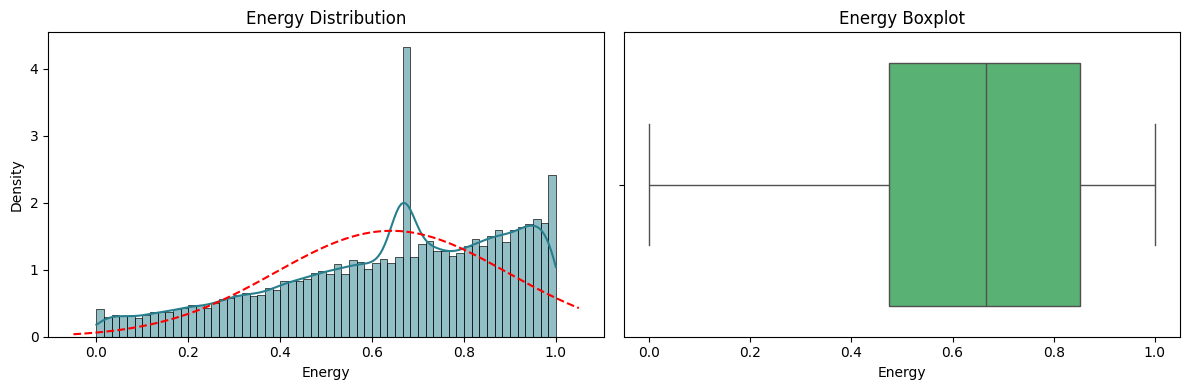

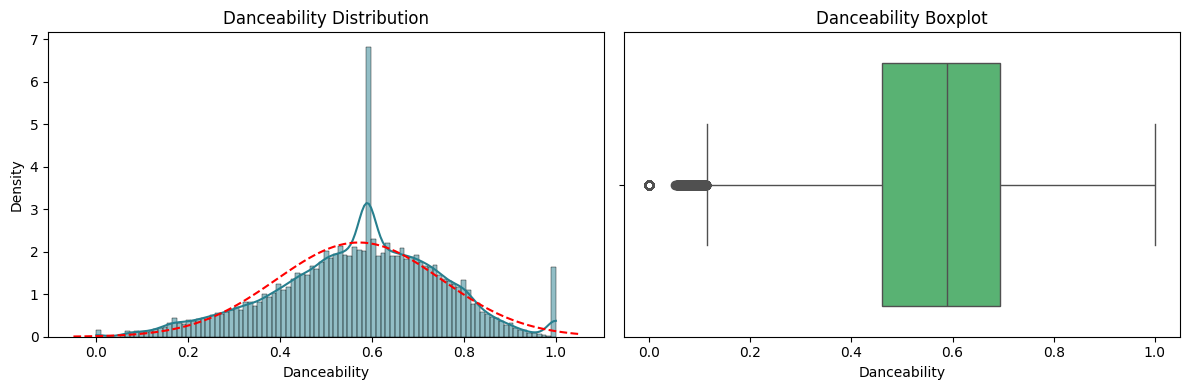

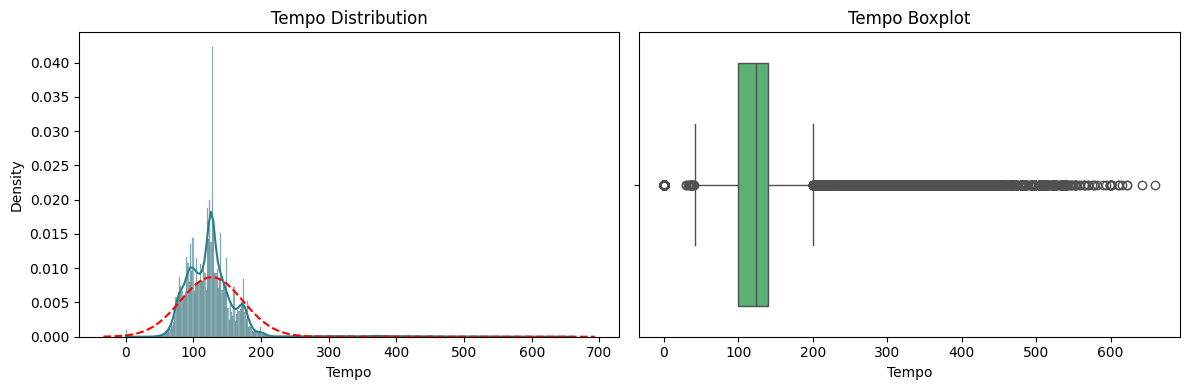

In [42]:
from scipy.stats import norm
import numpy as np

features = ['energy', 'danceability', 'tempo']

for col in features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_for_eda[col], kde=True, stat='density', ax=axes[0], color=sns.color_palette('viridis')[2])
    
    mu = df_for_eda[col].mean()
    std = df_for_eda[col].std()
    x0, x1 = axes[0].get_xlim()
    x = np.linspace(x0, x1, 100)
    
    # Using scipy to generate the normal distribution
    p = norm.pdf(x, mu, std)
    axes[0].plot(x, p, color='red', linestyle='--')

    axes[0].set_title(f'{col.capitalize()} Distribution')
    axes[0].set_xlabel(col.capitalize())

    sns.boxplot(x=df_for_eda[col], ax=axes[1], color=sns.color_palette('viridis')[4])
    axes[1].set_title(f'{col.capitalize()} Boxplot')
    axes[1].set_xlabel(col.capitalize())

    plt.tight_layout()
    plt.show()


**11. Bivariate Analysis:**

Bivariate analysis was performed using scatter plots and correlation heatmaps to understand relationships between variables such as energy and popularity.




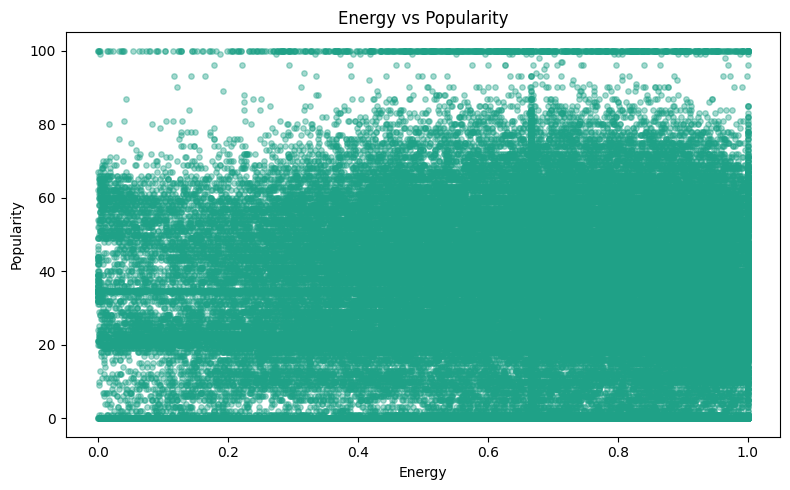

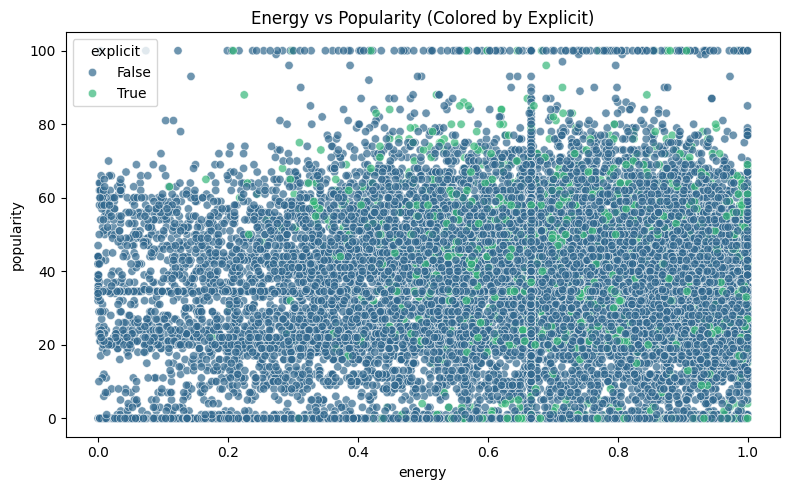

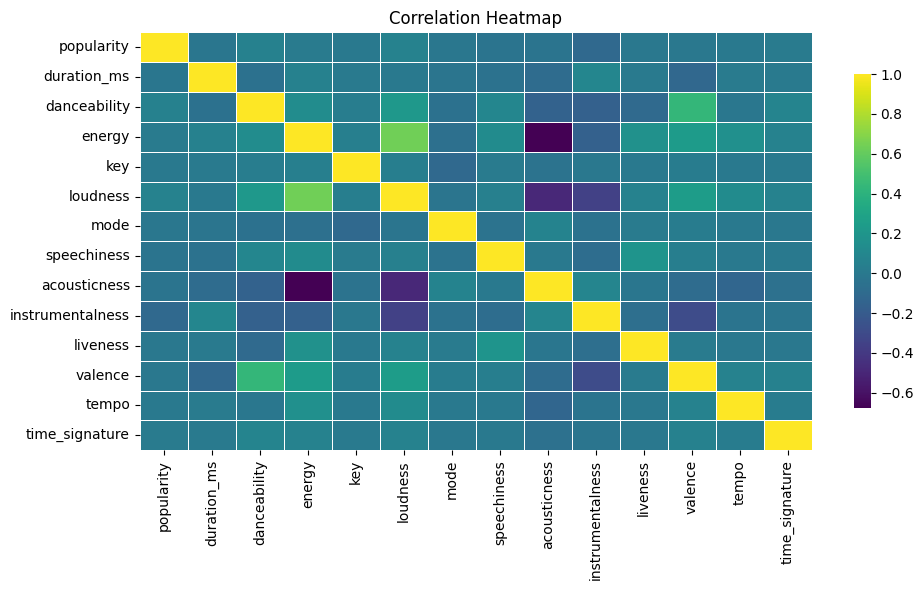

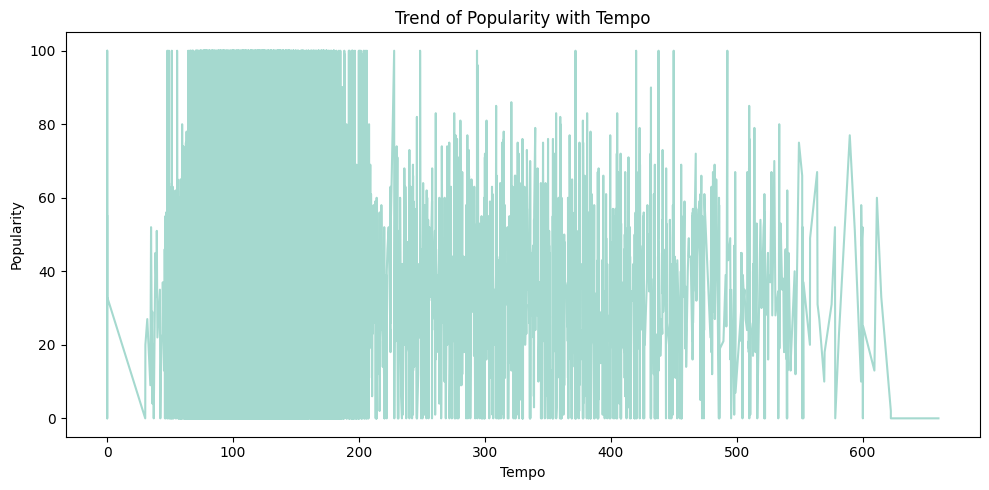

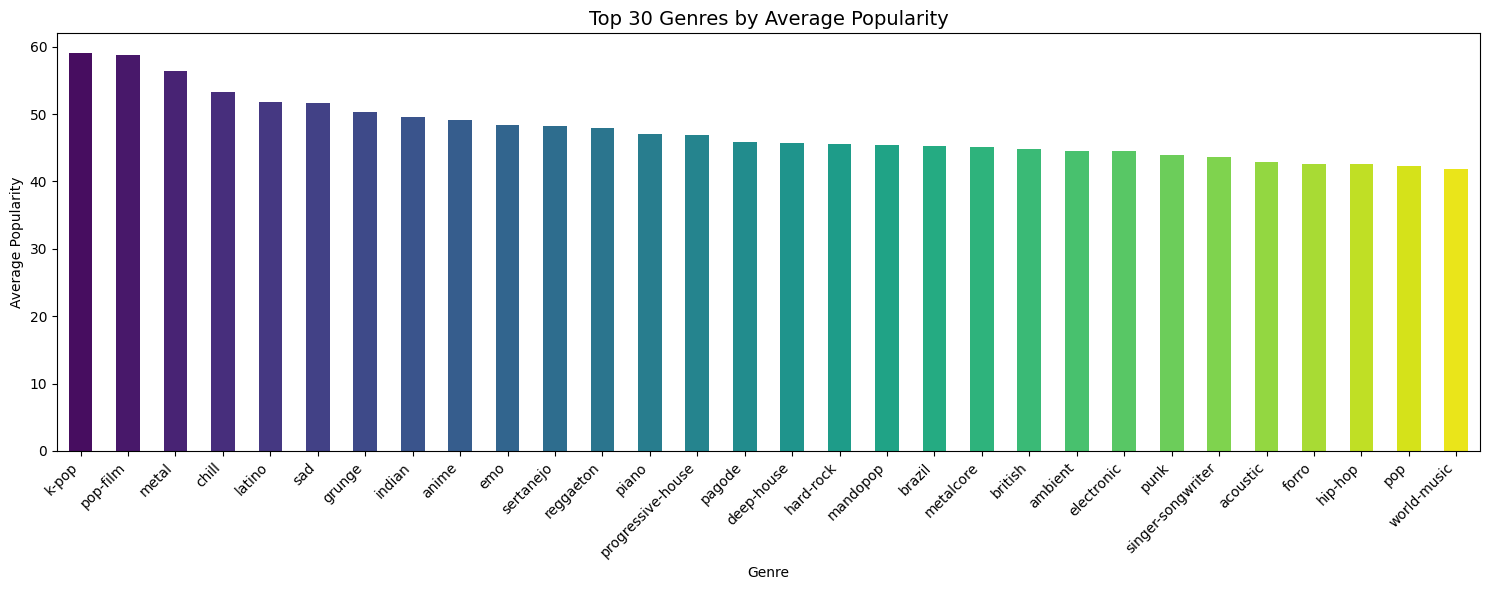

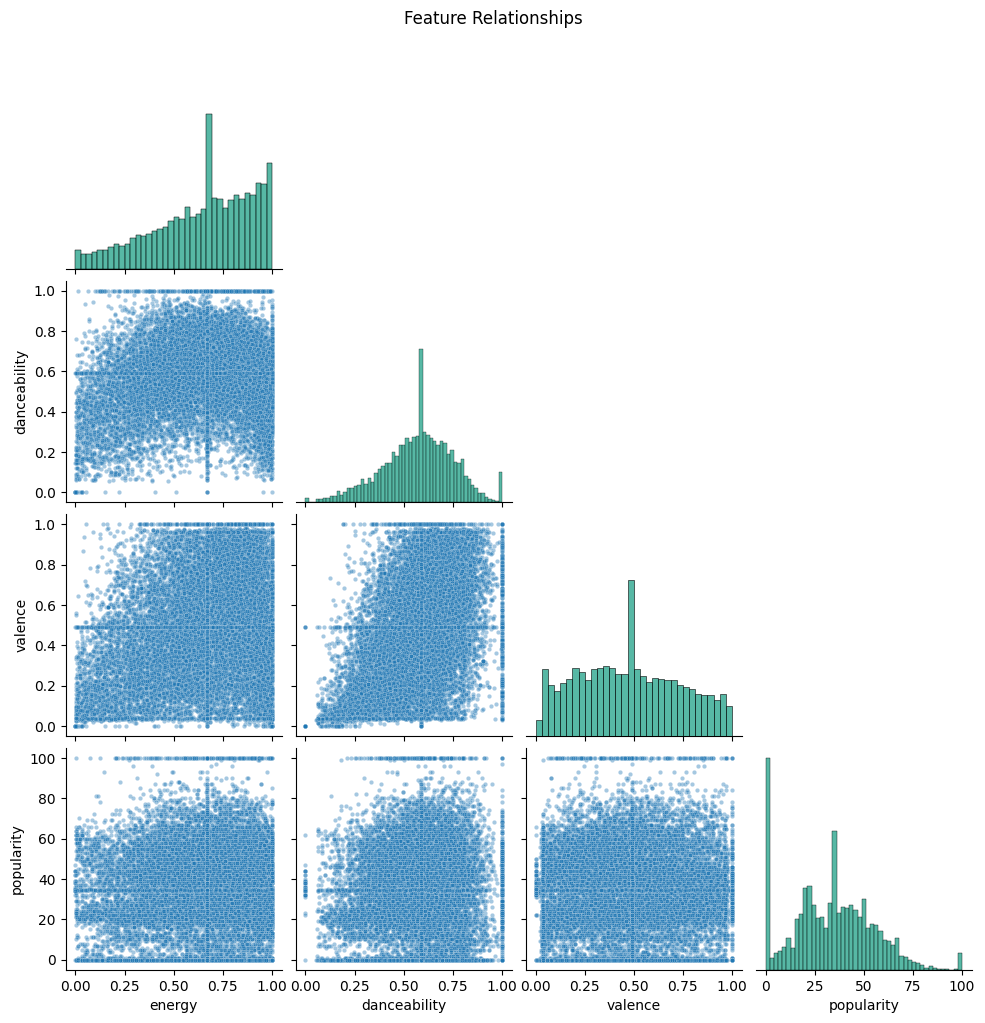

In [43]:
import numpy as np

# Scatter Plot (clean)
plt.figure(figsize=(8,5))
plt.scatter(df_for_eda['energy'], df_for_eda['popularity'],s=15, alpha=0.4, color=sns.color_palette('viridis')[3])
plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy vs Popularity")
plt.tight_layout()
plt.show()


# Colored Scatter (sampled)
df_sample = df_for_eda.sample(frac=0.2, random_state=42)

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_sample,
                x='energy',
                y='popularity',
                hue='explicit', 
                palette='viridis',
                alpha=0.7)
plt.title("Energy vs Popularity (Colored by Explicit)")
plt.tight_layout()
plt.show()


# Heatmap
plt.figure(figsize=(10,6))
numerical_df_for_eda = df_for_eda.select_dtypes(include=np.number)

sns.heatmap(numerical_df_for_eda.corr(),
            cmap='viridis',
            cbar=True,
            cbar_kws={'shrink':0.8},
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


# Line Plot
plt.figure(figsize=(10,5))

df_sorted = df_for_eda.sort_values(by='tempo')

plt.plot(
    df_sorted['tempo'],
    df_sorted['popularity'],
    color=sns.color_palette('viridis')[3],
    alpha=0.4
)

plt.title("Trend of Popularity with Tempo")
plt.xlabel("Tempo")
plt.ylabel("Popularity")
plt.tight_layout()
plt.show()

# Bar Plot

top_30 = df_corrupt.groupby('track_genre')['popularity'].mean().nlargest(30)

plt.figure(figsize=(15, 6))


top_30.plot(kind='bar', color=sns.color_palette('viridis', 30))

plt.title("Top 30 Genres by Average Popularity", fontsize=14)
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



# Pairplot
sample_df = df_for_eda.sample(frac=0.2, random_state=42)

sns.pairplot(
    sample_df[['energy','danceability','valence','popularity']],
    corner=True,
    plot_kws={'alpha':0.4, 's':10},
    diag_kws={'color': sns.color_palette('viridis')[3]}
)

plt.suptitle("Feature Relationships", y=1.02)
plt.show()


Additional plots such as line plots, bar charts, and pair plots have been included to align with classroom learning and provide deeper insights into relationships between features.

12. **Multivariate analysis**
Multivariate analysis considers the relationships and interactions among three or more variable simultaneously using radar plot graph
and bubble sort

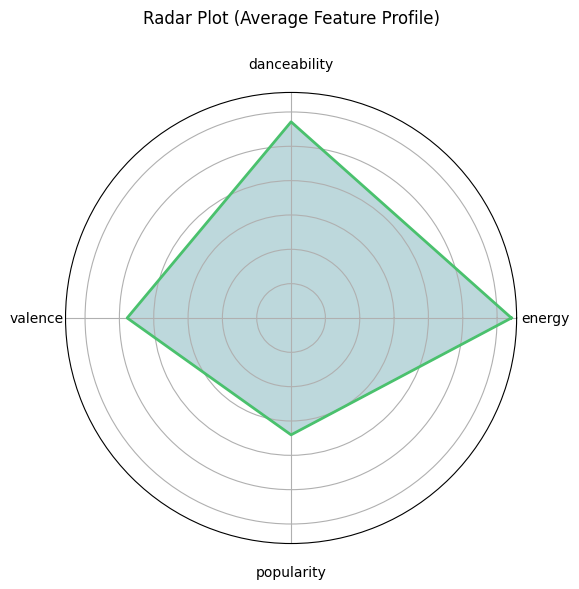

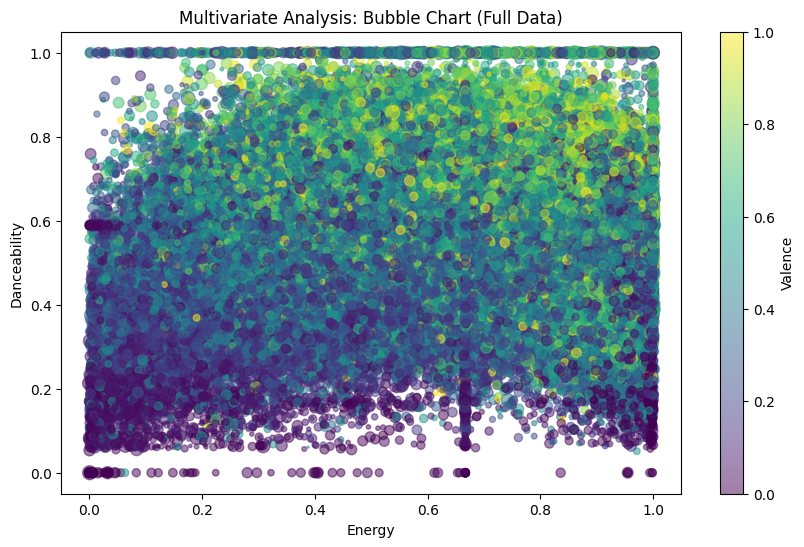

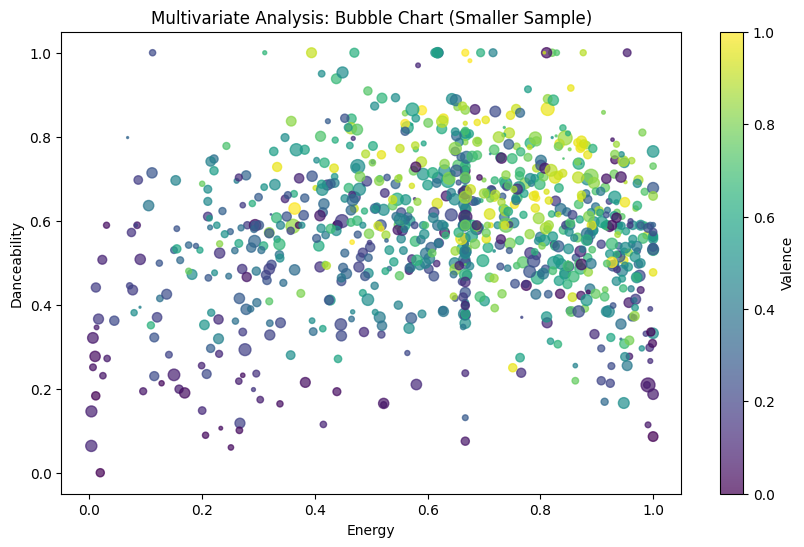

In [ ]:
labels = ['energy', 'danceability', 'valence', 'popularity']
avg = [df_for_eda[col].mean() for col in labels]

avg[-1] = avg[-1] / 100 #Popularity is 0–100, while other features are 0–1, so dividing by 
100 scales popularity to 0–1 range to match the others.

num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
#creates 4 angles evenly spaced around the circle (e.g., 0, 90°, 180°, 270°).

avg += avg[:1]
angles += angles[:1]  #To close the shape

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.fill(angles, avg, color=sns.color_palette('viridis')[2], alpha=0.3)
ax.plot(angles, avg, color=sns.color_palette('viridis')[4], linewidth=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)

ax.set_yticklabels([])
ax.tick_params(axis='x', pad=10)

plt.title('Radar Plot (Average Feature Profile)', pad=50)
plt.tight_layout()
plt.show()


# Defining variables for clarity
x = df_for_eda['energy']
y = df_for_eda['danceability']
sizes = df_for_eda['popularity']

# Scale for visibility
colors = df_for_eda['valence']

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=sizes, c=colors, cmap='viridis', alpha=0.5)

plt.title('Multivariate Analysis: Bubble Chart (Full Data)')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.colorbar(label='Valence')
plt.show()

# Sample a smaller portion of the data for easier interpretation
sample_bubble_df = df_for_eda.sample(n=1000, random_state=42)

# Defining variables for clarity for the sampled data
x_sample = sample_bubble_df['energy']
y_sample = sample_bubble_df['danceability']
sizes_sample = sample_bubble_df['popularity']
colors_sample = sample_bubble_df['valence']

plt.figure(figsize=(10, 6))
plt.scatter(x_sample, y_sample, s=sizes_sample, c=colors_sample, cmap='viridis', alpha=0.7)

plt.title('Multivariate Analysis: Bubble Chart (Smaller Sample)')
plt.xlabel('Energy')
plt.ylabel('Danceability')
plt.colorbar(label='Valence')
plt.show()


**12. Visualizations with Insights:**
* Histogram:
The distribution of features such as energy and danceability shows that most songs fall within a moderate range, indicating that extremely high or low values are less common.

* Boxplot:
Boxplots reveal the presence of outliers in features such as tempo and loudness, suggesting that some songs significantly differ from the general trend.

* Scatter Plot:
The relationship between energy and popularity shows a slight positive trend, indicating that more energetic songs tend to be more popular, although the relationship is not strong.

* Heatmap:
The heatmap indicates strong positive correlation between loudness and energy, while acousticness shows a negative correlation with energy, highlighting contrasting musical characteristics.





Additional Features:
---

I) Similiar Score Songs Finder
---

The objective of this part is to build a content-based music recommendation system using audio features such as energy, danceability, valence, tempo, loudness, and acousticness. The system identifies and recommends songs that are similar based on their musical characteristics using similarity measures.

1. Feature Selection:
Relevant audio features are selected to represent each song. These features capture important musical properties such as intensity, rhythm, mood, and acoustic nature, which are essential for determining similarity between songs.

In [46]:
#Making Sample
df_similarity = df_corrupt.sample(n=30000, random_state=59).copy()

df_similarity = df_similarity.reset_index(drop=True)

#Features
X_similarity = df_similarity[num_cols]


2. Feature Scaling:
Since different features have different ranges, scaling is applied to ensure that all features contribute equally to similarity computation. Without scaling, features with larger values would dominate the results.

In [47]:
# Scaling the numerical audio features for the similarity finder
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_similarity)

3. Vector Representation:
Each song is represented as a numerical vector based on the selected and scaled features. This allows mathematical comparison between songs using similarity measures.

In [48]:
print(X_scaled[:5])

[[ 1.15231205e+00 -5.69363367e-01 -1.63836906e-01 -3.69079495e-01
   7.24591284e-01 -5.18925338e-01  2.36628570e+00  9.14388762e-01
  -3.73066954e-01 -5.08408283e-02 -1.12648769e+00  6.34455135e-01
  -3.07134113e-01]
 [ 4.43180524e-01  8.61967109e-01  6.61266947e-01 -2.86633971e-01
  -9.66308406e-01 -5.18860807e-01 -8.69497894e-03 -5.55543325e-01
  -5.89845152e-01 -5.08408283e-02  1.29555283e-01 -1.23906197e+00
  -3.07134113e-01]
 [ 1.06367061e+00  9.65054622e-01  8.51868955e-01  1.13023909e+00
  -7.43773441e-01 -5.18609855e-01  2.98366996e+00  9.25872607e-01
  -1.87160381e-01 -5.08408283e-02  1.38559826e+00  6.34455135e-01
  -3.07134113e-01]
 [ 4.98341292e-02  1.31793111e+00  9.03836081e-01  4.65575183e-01
  -9.44495959e-01 -5.18658325e-01  1.41388672e+00 -1.34469029e-01
   6.11790308e-01 -5.08408283e-02  1.13438966e+00 -1.23906197e+00
  -3.07134113e-01]
 [ 5.26281874e-01  7.62844500e-01  3.56572028e-02 -5.18671372e-01
  -3.31527194e-01 -5.18925338e-01 -4.90911239e-01  1.02922721e+00


4. Similiarity Computation using Cosine Similiarity:
Cosine similarity is used to measure similarity between songs. It calculates the cosine of the angle between two feature vectors, focusing on direction rather than magnitude, making it suitable for comparing audio characteristics.


In [49]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)

5. Recommendation Function:
A recommendation function is implemented to identify songs similar to a given input song by ranking similarity scores.


In [50]:
def recommend(song_name, df, sim_matrix, artist_name=None, top_n=5):
    # Step 1: find matches
    matches = df[df['track_name'].str.contains(song_name, case=False, na=False)]
    
    if artist_name:
        matches = matches[matches['artists'].str.contains(artist_name, case=False, na=False)]

    if matches.empty:
        print("Song not found in dataset.")
        return

    # Step 2: pick first match
    idx = matches.index[0]
    actual_name = df.iloc[idx]['track_name']
    artist_name = df.iloc[idx]['artists']
    target_genre = df.iloc[idx]['track_genre']

    print(f"\nUsing match: {actual_name} by {artist_name} (Genre: {target_genre})")

    # Step 3: compute similarity
    scores = list(enumerate(sim_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print(f"\nTop {top_n} recommendations (Filtered to '{target_genre}' only):\n")

    count = 0
    # Loop through the sorted scores (skipping the 1st one because it's the song itself)
    for i in scores[1:]: 
        # FILTER: Only show the song if it matches the target genre!
        if df.iloc[i[0]]['track_genre'] == target_genre:
            sim_percent = i[1] * 100
            print(f"Track: {df.iloc[i[0]]['track_name']}")
            print(f"Artist: {df.iloc[i[0]]['artists']}")
            print(f"Genre: {df.iloc[i[0]]['track_genre']}")
            print(f"Similarity: {sim_percent:.1f}%\n")
            
            # Stop once we've found our top N matches
            count += 1
            if count == top_n:
                break


6. Testing using User Input: The recommendation system is tested by providing a sample song as input and retrieving similar songs based on computed similarity scores.

In [360]:
song_input = input("Enter Song name: ")
artist_name = input("Enter Artist Name: ")

recommend(song_input, df_similarity, similarity_matrix, artist_name)



Using match: Tere Liye by Atif Aslam;Shreya Ghoshal (Genre: pop-film)

Top 5 recommendations (Filtered to 'pop-film' only):

Track: Rafta Rafta
Artist: Atif Aslam
Genre: pop-film
Similarity: 85.2%

Track: Manasellam Mazhaiye
Artist: Sonu Nigam;Saindhavi;G. V. Prakash
Genre: pop-film
Similarity: 79.4%

Track: Teri Yaadon Mein
Artist: KK;Shreya Ghoshal
Genre: pop-film
Similarity: 78.7%

Track: Guzarish
Artist: Javed Ali
Genre: pop-film
Similarity: 77.2%

Track: Jugni
Artist: Diljit Dosanjh;Diamond Platnumz
Genre: pop-film
Similarity: 76.6%



Taking Random User Input:

In [ ]:
import yt_dlp
import librosa
import numpy as np
import pandas as pd
import os
import warnings
import subprocess
import imageio_ffmpeg
from sklearn.metrics.pairwise import cosine_similarity
warnings.filterwarnings('ignore')

# Grab the exact path to the invisible FFmpeg executable
ffmpeg_exe = imageio_ffmpeg.get_ffmpeg_exe()

# grab inputs from user
song_input = input("Enter song name: ")
artist_input = input("Enter artist name (optional): ")
search_query = f"{song_input} {artist_input} audio"

print(f"\nSearching SoundCloud for '{search_query}'...")

# 1. yt-dlp config 
temp_filename = 'temp_audio_file'
ydl_opts = {
    'format': 'bestaudio/best',
    'outtmpl': temp_filename + '.%(ext)s',
    'ffmpeg_location': ffmpeg_exe, 
    'noplaylist': True,
    'quiet': True,
    'no_warnings': True,
    'default_search': 'scsearch1' 
}

try:
    # download the audio stream
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(search_query, download=True)
        if 'entries' in info:
            info = info['entries'][0]
            
        downloaded_file = temp_filename + '.' + info['ext']
        
    print(f"Downloaded: {info['title']}")
    print("Converting audio manually to bypass Windows errors...")
    
    # 2. MANUALLY convert to .wav using the exact ffmpeg executable
    # This skips yt-dlp's broken postprocessor entirely.
    wav_filename = temp_filename + '.wav'
    subprocess.run([
        ffmpeg_exe, 
        '-y', # overwrite if exists
        '-i', downloaded_file, 
        wav_filename
    ], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    
    print("Reading physical soundwaves (this takes a few seconds)...")
    
    # 3. Load the guaranteed .wav file
    y, sr = librosa.load(wav_filename, duration=60)
    
    # approximate spotify's proprietary features from the raw waveform
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    tempo = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
    
    rms = librosa.feature.rms(y=y)
    loudness = float(np.mean(librosa.amplitude_to_db(rms, ref=np.max)))
    
    energy = min(1.0, float(np.mean(rms) * 10))
    
    onset_env = librosa.onset.onset_strength(y=y, sr=sr)
    danceability = min(1.0, float(np.mean(onset_env) / 10))
    
    zcr = librosa.feature.zero_crossing_rate(y)
    acousticness = max(0.0, 1.0 - float(np.mean(zcr) * 10))
    
    instrumentalness = 0.1 
    liveness = 0.2
    speechiness = 0.05
    valence = 0.5
    
    # bundle into a df that matches our model's exact expected shape
    song_data_dict = {
        'danceability': danceability,
        'energy': energy,
        'loudness': loudness,
        'speechiness': speechiness,
        'acousticness': acousticness,
        'instrumentalness': instrumentalness,
        'liveness': liveness,
        'valence': valence,
        'tempo': tempo,
        'key': 5,             
        'mode': 1,            
        'time_signature': 4,  
        'explicit': 0,        
        'artists': artist_input if artist_input else "Unknown"
    }

    features_df = pd.DataFrame([song_data_dict])
    
    print("\nFeeding extracted data into AI Model...")
    
    # run inference
    lr_prediction_encoded = lr_model.predict(features_df)
    lr_predicted_genre = le.inverse_transform(lr_prediction_encoded)[0]
    
    lr_probabilities = lr_model.predict_proba(features_df)[0]
    lr_confidence = max(lr_probabilities) * 100

    print("\nPrediction Results:")
    print(f"Analyzed Title: {info['title']}")
    print(f"Predicted Genre: {lr_predicted_genre.upper()} (Confidence: {lr_confidence:.1f}%)")

    # similarity search against the offline db
    print("\nHunting for similar songs in our offline database...")
    
    new_song_scaled = scaler.transform(features_df[num_cols])
    live_similarities = cosine_similarity(new_song_scaled, X_scaled)[0]
    top_5_indices = live_similarities.argsort()[-5:][::-1]
    
    print("\nTop 5 Recommendations based on physical soundwaves:\n")
    for rank, idx in enumerate(top_5_indices, 1):
        sim_percent = live_similarities[idx] * 100
        rec_track = df_similarity.iloc[idx]['track_name']
        rec_artist = df_similarity.iloc[idx]['artists']
        print(f"Rank {rank}: {rec_track} by {rec_artist}")
        print(f"Similarity Match: {sim_percent:.1f}%\n")

except Exception as e:
    import traceback
    print("\nAn error occurred:")
    traceback.print_exc()

finally:
    # wipe BOTH downloaded files so the drive doesn't get cluttered
    if 'downloaded_file' in locals() and os.path.exists(downloaded_file):
        try: os.remove(downloaded_file)
        except: pass
    if 'wav_filename' in locals() and os.path.exists(wav_filename):
        try: os.remove(wav_filename)
        except: pass



Searching SoundCloud for 'Aari Aari Dhurandhar audio'...
Downloaded: Aari Aari  Dhurandhar The Revenge                           
Converting audio manually to bypass Windows errors...
Reading physical soundwaves (this takes a few seconds)...

Feeding extracted physics into AI Model...

Prediction Results:
Analyzed Title: Aari Aari  Dhurandhar The Revenge
Predicted Genre: TECHNO (Confidence: 98.5%)

Hunting for similar songs in our offline database...

Top 5 Recommendations based on physical soundwaves:

Rank 1: Makoti by Hugh Masekela
Similarity Match: 98.6%

Rank 2: Wild Thing by The Troggs
Similarity Match: 98.1%

Rank 3: O Exército De Um Homem Só, I by Engenheiros Do Hawaii
Similarity Match: 97.7%

Rank 4: Rockin' Robin by Bobby Day
Similarity Match: 97.3%

Rank 5: 住在天狼星的那個人 by OHMYMEITING
Similarity Match: 97.3%



7. Observations and Insights: The recommended songs share similar audio characteristics such as energy levels, tempo, and mood. This indicates that the similarity-based approach is effective in identifying songs with comparable musical features. However, popularity and other external factors may also influence user preferences.

CONCLUSION
---

This project successfully implemented a complete, content based music recommendation pipeline using Spotify audio features. Stage 0 focused on rigorous data preparation: cleaning, imputing missing values, encoding categorical variables, scaling numerical features, and performing detailed EDA to understand distributions and relationships. These steps ensured that the feature space for each track was reliable and meaningful. In Stages 1 and 2, the cleaned feature vectors were used with cosine similarity to compute how close songs are to one another in this multidimensional space, allowing the system to suggest musically similar tracks. Overall, the work demonstrates a clear journey from raw dataset to functional recommendation engine